In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/customer_churn.csv"
)

df.head()

,frequency,monetary,avg_order_value,category_count,avg_review_score,avg_delivery_days,total_freight_paid,recency_days,customer_tenure_days,cluster,customer_segment,clv,churn,customer_segment_encoded
0,1,141.90,141.90,1,5.0,6.0,12.00,115,115,2,Active Customers,44.708219,0,0
1,1,27.19,27.19,1,4.0,3.0,8.29,118,118,2,Active Customers,8.790192,0,0
2,1,86.22,86.22,1,3.0,25.0,17.22,541,541,0,Inactive Customers,127.794575,1,2
3,1,43.62,43.62,1,4.0,20.0,17.63,325,325,0,Inactive Customers,38.839726,0,2
4,1,196.89,196.89,1,5.0,13.0,16.89,292,292,0,Inactive Customers,157.512000,0,2


In [2]:
import numpy as np

df["monetary_log"] = np.log1p(
    df["monetary"]
)

In [32]:
features = [
    "frequency",
    "avg_order_value",
    "category_count",
    "avg_review_score",
    "avg_delivery_days",
    "total_freight_paid",
    "customer_segment_encoded"
]

# features = [
#     "frequency",
#     "category_count",
#     "avg_review_score",
#     "avg_delivery_days",
#     "total_freight_paid",
#     "customer_segment_encoded"
# ]

In [33]:
X = df[features]

y = df["monetary_log"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
y_pred_rf = rf.predict(
    X_test
)

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

MAE: 0.08597149509425424
RMSE: 0.2044437778511333
R2: 0.9494528320484517


In [38]:
rf_results = pd.DataFrame({
    "Metric":[
        "MAE",
        "RMSE",
        "R2"
    ],
    "Value":[
        mae_rf,
        rmse_rf,
        r2_rf
    ]
})

rf_results

,Metric,Value
0,MAE,0.085971
1,RMSE,0.204444
2,R2,0.949453


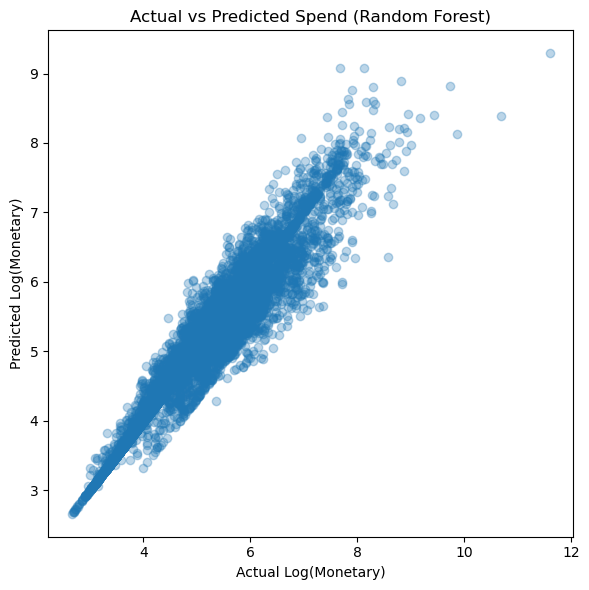

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.3
)

plt.title(
    "Actual vs Predicted Spend (Random Forest)"
)

plt.xlabel(
    "Actual Log(Monetary)"
)

plt.ylabel(
    "Predicted Log(Monetary)"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/spend_actual_vs_predicted_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
residuals = y_test - y_pred_rf

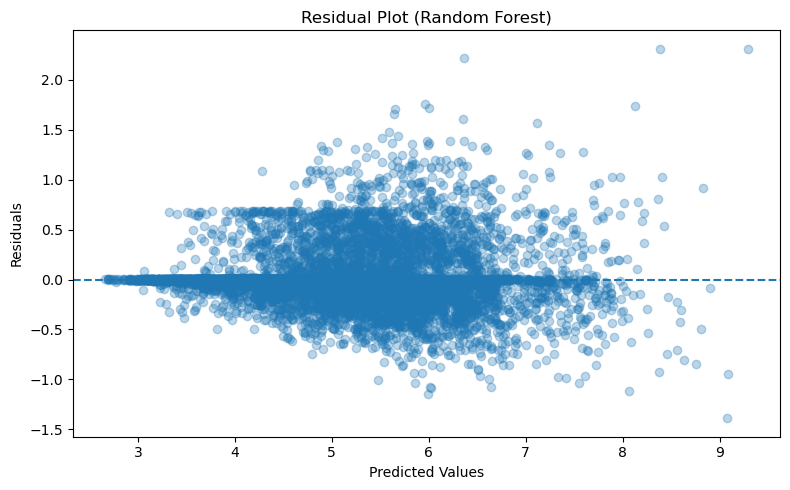

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_rf,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Residual Plot (Random Forest)"
)

plt.xlabel(
    "Predicted Values"
)

plt.ylabel(
    "Residuals"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/residual_plot_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
1,avg_order_value,0.867505
5,total_freight_paid,0.070639
6,customer_segment_encoded,0.040076
4,avg_delivery_days,0.012558
3,avg_review_score,0.004149
2,category_count,0.002722
0,frequency,0.002351


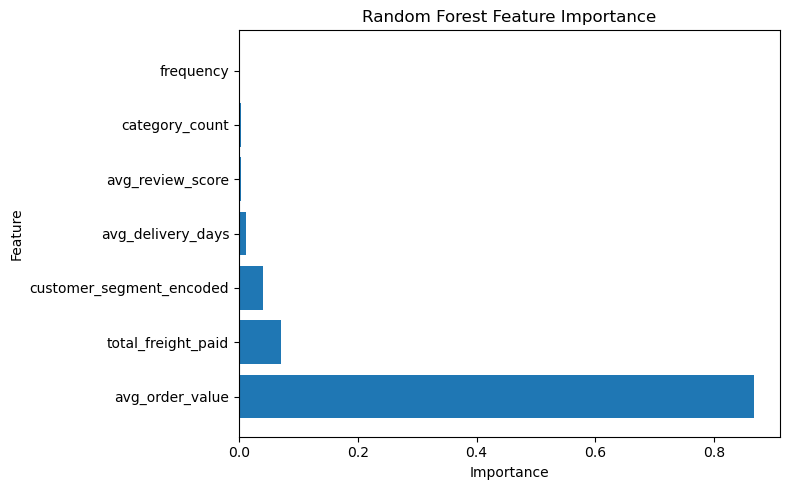

In [43]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/rf_regression_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
comparison = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest"
    ],
    "MAE":[
        0.426,
        mae_rf
    ],
    "RMSE":[
        0.633,
        rmse_rf
    ],
    "R2":[
        0.515,
        r2_rf
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.426000,0.633000,0.515000
1,Random Forest,0.085971,0.204444,0.949453


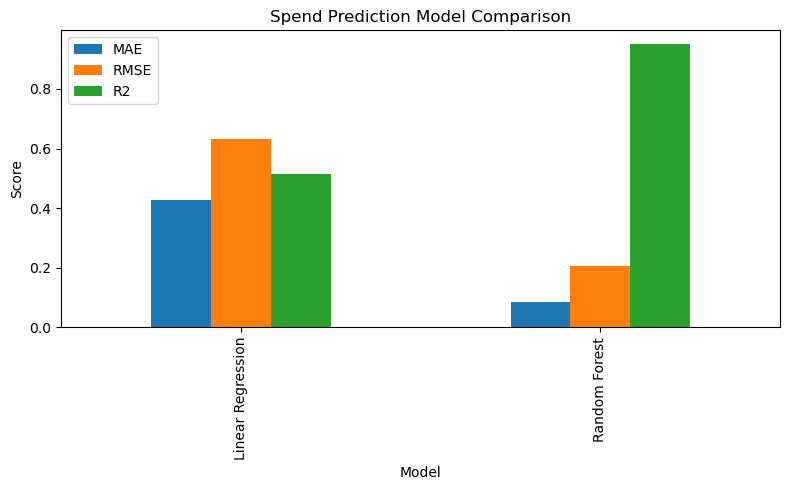

In [45]:
comparison.set_index(
    "Model"
).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Spend Prediction Model Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Score"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/spend_model_comparison_partial.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
import joblib

joblib.dump(
    rf,
    "../models/spend_prediction_rf.pkl"
)

['../models/spend_prediction_rf.pkl']